# TRIBE v2 Demo: Predicting Brain Responses to Naturalistic Stimuli

[TRIBE v2](https://github.com/facebookresearch/tribev2) is a deep multimodal brain encoding model that predicts **fMRI brain responses** to naturalistic stimuli — video, audio, and text.

It combines state-of-the-art feature extractors — **LLaMA 3.2** (text), **V-JEPA2** (video), and **Wav2Vec-BERT** (audio) — into a unified Transformer that maps multimodal representations onto the cortical surface (**fsaverage5**, ~20k vertices).

In this notebook, we will:
1. Load a pretrained TRIBE v2 model from HuggingFace
2. Predict brain responses to a **video** clip
3. Predict brain responses to **audio** generated from text
4. Visualize the predicted activity on a 3D brain surface

## Setup (for Colab users)

1. Activate the GPU (Menu > Runtime > Change runtime)
2. Run the command below
3. Restart your environment for the new packages to be taken into account

In [1]:
# Taken from hardened import list from https://www.youtube.com/watch?v=VER-F4wdA9Q

from importlib import metadata
from importlib import import_module
import subprocess
import sys


def parse_major_minor(version: str) -> tuple[int, int]:
    parts = []
    for token in version.split("."):
        digits = "".join(ch for ch in token if ch.isdigit())
        if not digits:
            break
        parts.append(int(digits))
        if len(parts) == 2:
            break
    while len(parts) < 2:
        parts.append(0)
    return tuple(parts)


required_dists = [
    "tribev2",
    "yt-dlp",
    "Pillow",
    "exca",
    "nibabel",
    "nilearn",
    "neuralset",
    "neuraltrain",
]
missing = []
installed = {}
for dist_name in required_dists + ["numpy", "scipy"]:
    try:
        installed[dist_name] = metadata.version(dist_name)
    except metadata.PackageNotFoundError:
        missing.append(dist_name)

numpy_ok = False
scipy_ok = False
if "numpy" in installed:
    numpy_ok = parse_major_minor(installed["numpy"]) < (2, 1)
if "scipy" in installed:
    scipy_mm = parse_major_minor(installed["scipy"])
    scipy_ok = (1, 13) <= scipy_mm < (1, 16)

import_failures = []
for module_name in ["PIL", "moviepy", "exca", "nibabel", "nilearn", "neuralset", "neuraltrain"]:
    try:
        import_module(module_name)
    except Exception as exc:
        import_failures.append(f"{module_name}: {type(exc).__name__}: {exc}")

needs_install = bool(missing) or not numpy_ok or not scipy_ok or bool(import_failures)

if needs_install:
    print("Installing notebook dependencies...")
    if missing:
        print("Missing distributions:", ", ".join(missing))
    if import_failures:
        print("Broken imports detected:")
        for failure in import_failures:
            print(" -", failure)
    if "numpy" in installed:
        print("Detected NumPy:", installed["numpy"])
    if "scipy" in installed:
        print("Detected SciPy:", installed["scipy"])

    # Install the full notebook stack first, then force NumPy/SciPy back to a
    # known-good range for TRIBE's compiled dependencies.
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git",
            "exca",
            "yt-dlp",
            "pillow",
            "pandas",
            "matplotlib",
            "moviepy",
        ],
        check=True,
    )

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--force-reinstall",
            "numpy>=1.26.4,<2.1",
            "scipy>=1.13,<1.16",
        ],
        check=True,
    )

    raise SystemExit(
        "Install complete. Restart the runtime now, then run the notebook again from the top."
    )

print("Setup already looks correct.")
print(f"NumPy version: {installed['numpy']}")
print(f"SciPy version: {installed['scipy']}")

Setup already looks correct.
NumPy version: 2.0.2
SciPy version: 1.15.3


## Loading the model

We load TRIBE v2 model from [HuggingFace Hub](https://huggingface.co/facebook/tribev2). On the first run, this downloads the model checkpoint and config (~1 GB). Subsequent runs use the cached version.

We also initialize a `PlotBrain` object for 3D brain surface visualization using the **fsaverage5** mesh.

In [3]:
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path("./cache")

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
    config_update={
        "data": {
            "features_to_use": ["audio", "video"] # can also do ["audio", "video"]
        }
    },
)
plotter = PlotBrain(mesh="fsaverage5")

2026-04-30 21:30:07 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt


## Predict brain responses to a video

Given a video file, TRIBE v2 automatically:
1. **Extracts audio** from the video track
2. **Transcribes speech** into word-level events with timestamps using [**WhisperX**](https://github.com/m-bain/whisperx)
3. **Extracts visual features** (DINOv2 + V-JEPA2) and **audio features** (Wav2Vec-BERT) and **text features** (LLaMA 3.2)
4. **Predicts fMRI activity** at each time step (1 TR = 1 second) across the cortical surface

Below, we download a sample video ([Sintel trailer](https://durian.blender.org/)), build an events dataframe, and run the model.

In [5]:
# USING SAMPLE VIDEO
video_path = CACHE_FOLDER / "sample_video.mp4"
url = "https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4"
download_file(url, video_path)


# df = model.get_events_dataframe(video_path=video_path)
# display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

import pandas as pd
from neuralset.events.utils import standardize_events
from neuralset.events.transforms import (
    ExtractAudioFromVideo,
    ChunkEvents,
)

# 1. Define the internal TRIBE transforms (excluding transcription)
# These match the logic in the Meta source code for get_audio_and_text_events
transforms = [
    ExtractAudioFromVideo(),
    ChunkEvents(event_type_to_chunk="Audio", max_duration=60, min_duration=30),
    ChunkEvents(event_type_to_chunk="Video", max_duration=60, min_duration=30),
]

# 2. Build the initial event row
initial_event = {
    "type": "Video",
    "filepath": str(video_path),
    "start": 0,
    "timeline": "default",
    "subject": "default",
}

# 3. Process the file through the neuralset pipeline
df = standardize_events(pd.DataFrame([initial_event]))
for transform in transforms:
    df = transform(df)

# 4. Standardize and display
df = standardize_events(df)
display(df.head(8)[["type", "start", "duration", "filepath"]])

INFO - Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4
INFO:tribev2.demo_utils:Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4
Extract audio from video events:   0%|          | 0/1 [00:00<?, ?it/s]

MoviePy - Writing audio in cache/sample_video.wav



Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00,  1.79it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


MoviePy - Done.


,type,start,duration,filepath
0,Audio,0.0,52.21,cache/sample_video.wav
1,Video,0.0,52.21,cache/sample_video.mp4


In [ ]:
# ------------------
# FOR PERSONAL, UNDER DEV - ARE YOU SURE YOU NEED TO RUN?
# ------------------

# video_path = CACHE_FOLDER / "sample_video.mp4"
# url = "https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4"
# download_file(url, video_path)

from google.colab import files
from pathlib import Path
import shutil
import pandas as pd

uploaded = files.upload()
filename = next(iter(uploaded))
video_path = CACHE_FOLDER / filename
shutil.move(filename, video_path)

# Replicating the study's manual approach
VIDEO_DURATION = 18.0  # Set this to the actual length of your video in seconds

events_data = [
    {
        "type": "Video",
        "filepath": str(video_path),
        "start": 0.0,
        "duration": VIDEO_DURATION,
        "timeline": video_path.stem
    }
]

df = pd.DataFrame(events_data)

# 3. Proceed with prediction as normal
display(df[["type", "start", "duration", "filepath"]])

### Run the model

We feed the events dataframe to `model.predict()`, which extracts features for each modality, runs them through the Transformer, and returns predicted brain activity.

NOTE: you will have to request access to the Llama-3.2 model using your HuggingFace account.

The output `preds` has shape `(n_timesteps, n_vertices)` — one prediction per second of stimulus, with ~20k cortical vertices. The `segments` list contains the corresponding time segments with their associated events.

In [6]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")


[21:31:22 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.32G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

video_preprocessor_config.json: 0.00B [00:00, ?B/s]

2026-04-30 21:31:52 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 52.21s at 24.0fps, shape (854, 480)):
cache/sample_video.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 52.21s at 24.0fps, shape (854, 480)):
cache/sample_video.mp4
Encoding video:   0%|          | 0/104 [00:00<?, ?it/s]2026-04-30 21:31:55 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (104, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (104, 20, 1408)
Encoding video: 100%|██████████| 104/104 [04:37<00:00,  2.67s/it]
[21:36:30 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-04-30 21:36:30 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[21:36:30 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: 

Predictions shape: (53, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

We plot the predicted fMRI activity for the first 15 time steps on the fsaverage5 cortical mesh. Each panel shows one second of predicted activity, with the corresponding stimulus frame displayed below. Predictions are offset by 5 seconds in the past, in order to compensate for the hemodynamic lag.

We see that as the image appears on the screen, the visual cortex lights up (t=4s), followed by the language network when the character starts to speak (t=12s).

Plotting...: 100%|██████████| 15/15 [00:02<00:00,  5.20it/s]


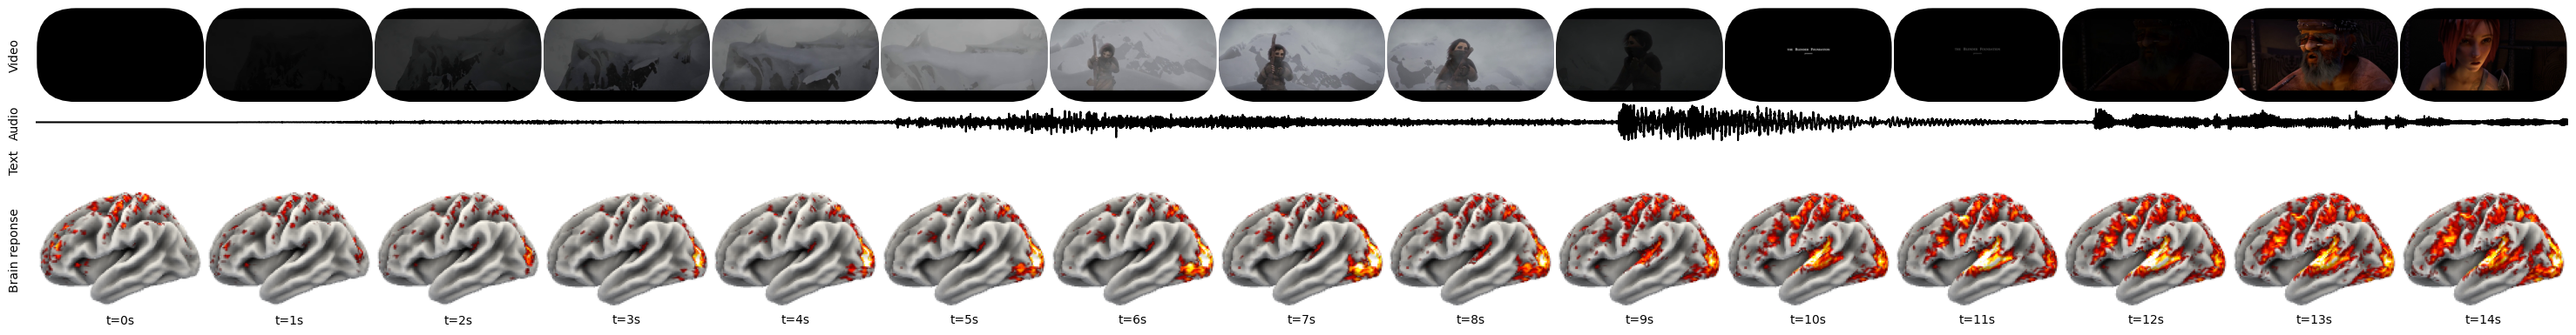

In [7]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

In [ ]:
# -------
# USER-FRIENDLY VIZ, UNDER DEV - DO YOU REALLY NEED TO RUN?
# ------

import matplotlib.pyplot as plt
import cv2
from tribev2.plotting.cortical import PlotBrainNilearn

# 1. Setup Plotter
nilearn_plotter = PlotBrainNilearn(mesh="fsaverage5")
steps_to_plot = [0, 4, 9, 14, 18]

# 2. Create the figure with specific 3D projections for the brain column
fig = plt.figure(figsize=(14, 4 * len(steps_to_plot)))

cap = cv2.VideoCapture(str(video_path))

for i, t_idx in enumerate(steps_to_plot):
    # --- LEFT: VIDEO FRAME (Standard 2D) ---
    cap.set(cv2.CAP_PROP_POS_MSEC, t_idx * 1000)
    ret, frame = cap.read()
    if ret:
        ax_img = fig.add_subplot(len(steps_to_plot), 2, 2*i + 1)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax_img.imshow(frame_rgb)
        ax_img.set_title(f"Video (t={t_idx})", fontsize=12)
        ax_img.axis("off")

    # --- RIGHT: BRAIN RESPONSE (3D Projection) ---
    # This specifically addresses your 'view_init' error
    ax_brain = fig.add_subplot(len(steps_to_plot), 2, 2*i + 2, projection='3d')

    # Plotting using the study's primary method
    nilearn_plotter.plot_surf(
        preds[t_idx],
        axes=ax_brain,
        views="left",
        cmap="fire",
        vmin=0.6,
        alpha_cmap=(0, 0.2)
    )
    ax_brain.set_title(f"Brain Activity (t={t_idx})", fontsize=12)

cap.release()
plt.tight_layout()
plt.show()